In [1]:
from pylab import *

In [3]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.4
Plasticnet version  0.1.12
macOS-15.3.1-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [29]:
# mu_c=0
# sigma_c=0
# mu_r=0
# sigma_r=0

mu_c=0
sigma_c=0
mu_r=0
sigma_r=0



base_sim_dir=f"sims-2025-02-25 mu {mu_c} sigma {sigma_c}"
if not os.path.exists(base_sim_dir):
    os.mkdir(base_sim_dir)
print(base_sim_dir)

sims-2025-02-25 mu 0 sigma 0


In [30]:
number_of_neurons=20
eta=1e-6
number_of_processes=8
#ray.init(num_cpus=number_of_processes)

In [31]:
#func=run_one_continuous_fix

noise_mat=linspace(0,1,11)

all_params=[]
for n,noise in enumerate(noise_mat):
    sfname=f'{base_sim_dir}/continuous fix {number_of_neurons} neurons noise {noise:.1f}.asdf'
    
    p=Struct()
    p.eta=eta
    p.number_of_neurons=number_of_neurons
    p.sfname=sfname
    p.mu_c=mu_c
    p.sigma_c=sigma_c
    p.mu_r=mu_r
    p.sigma_r=sigma_r
    
    p.noise=(noise,noise)
    
    all_params+=[p]

all_params=to_named_tuple(all_params)  

In [32]:
all_params[0]

params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-02-25 mu 0 sigma 0/continuous fix 20 neurons noise 0.0.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.0, 0.0), count=0)

In [39]:
RR={}
for params in tqdm(all_params):
    RR[params.sfname]=Results(params.sfname)

100%|███████████████████████████████████████████| 11/11 [00:10<00:00,  1.09it/s]


In [40]:
#assert func==run_one_continuous_fix

params=all_params[0]

sfname=params.sfname
noise=params.noise[1]

R=RR[sfname]
    
idx1,idx2=[_[1] for _ in R.sequence_index]
t=R.t/day



sims-2025-02-25 mu 0 sigma 0/continuous fix 20 neurons noise 0.0.asdf


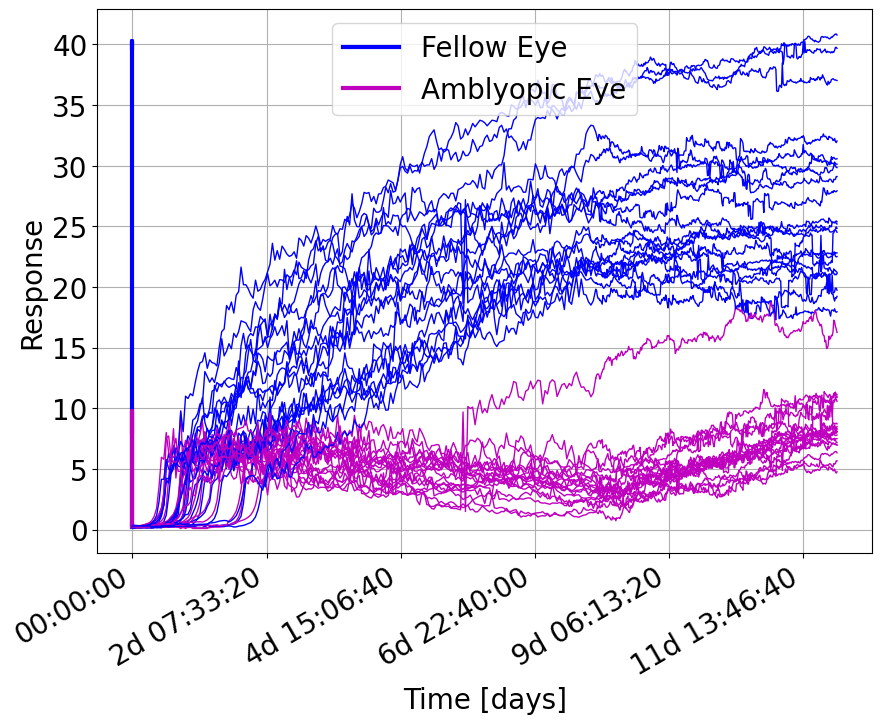

In [41]:
R=RR[params.sfname]
idx1,idx2=[_[1] for _ in R.sequence_index]
t=R.t/day

strong_i=1
weak_i=0


plot(t,R.y[:,0,strong_i],'b',label='Fellow Eye')
plot(t,R.y[:,0,weak_i],'m',label='Amblyopic Eye')

for n in range(number_of_neurons):
    plot(R.t,R.y[:,n,0],'m',lw=1)
    plot(R.t,R.y[:,n,1],'b',lw=1)
    
    
ylabel('Response')
xlabel('Time [days]')
legend()
print(params.sfname)
reformat_time_axis()  

(-1.2259791474784762, 30.05635751377943)

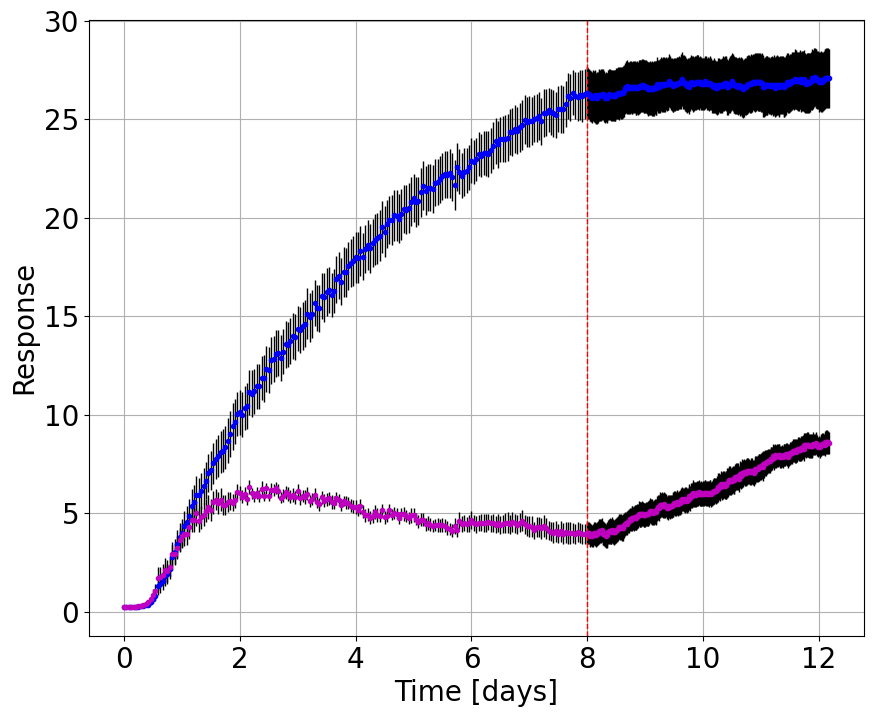

In [42]:
μ=R.y.mean(axis=1)  # average across neurons, at the end of a seq, for each channel
S=R.y.std(axis=1)
N=R.y.shape[1]
K=1+20/N**2
σ=K*S/np.sqrt(N)
errorbar(t,μ[:,strong_i],yerr=σ[:,strong_i],fmt='b.',lw=1,ecolor='k')
errorbar(t,μ[:,weak_i],yerr=σ[:,weak_i],fmt='m.',lw=1,ecolor='k')
ylabel('Response')
xlabel('Time [days]')

ylim=gca().get_ylim()
vlines(t[idx1],*ylim,'r',lw=1,ls='--')
gca().set_ylim(ylim)

(0.24227592521027413, 2.3412279730469407)

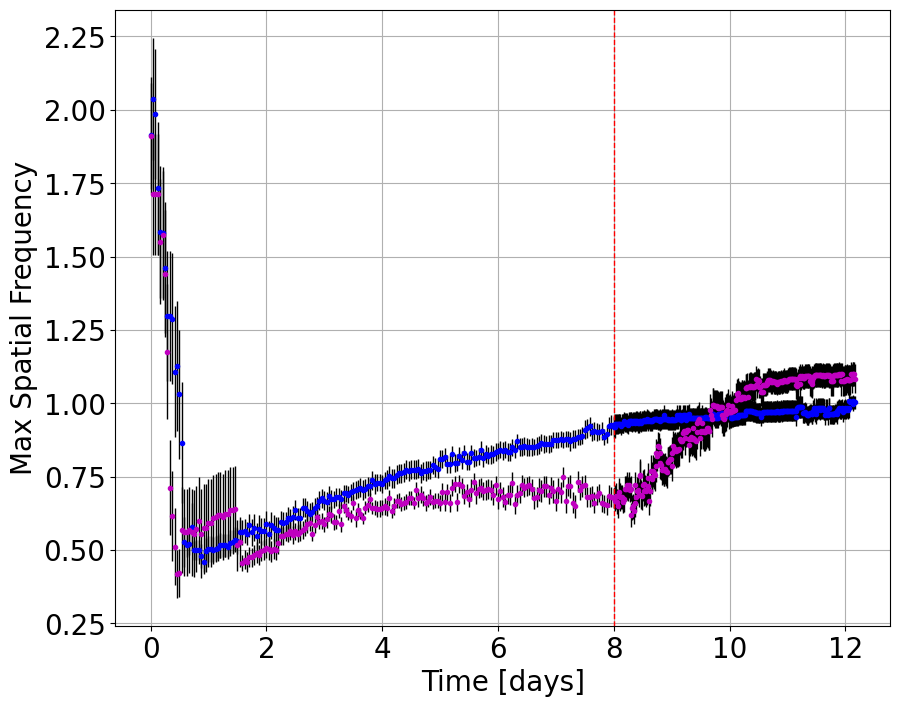

In [43]:
kk=R.max_SF
μ=kk.mean(axis=1)  # average across neurons, at the end of a seq, for each channel
S=kk.std(axis=1)
N=kk.shape[1]
K=1+20/N**2
σ=K*S/np.sqrt(N)
errorbar(t,μ[:,strong_i],yerr=σ[:,strong_i],fmt='b.',lw=1,ecolor='k')
errorbar(t,μ[:,weak_i],yerr=σ[:,weak_i],fmt='m.',lw=1,ecolor='k')
ylabel('Max Spatial Frequency')
xlabel('Time [days]')

ylim=gca().get_ylim()
vlines(t[idx1],*ylim,'r',lw=1,ls='--')
gca().set_ylim(ylim)




(0.12334298481308578, 2.8320958639581146)

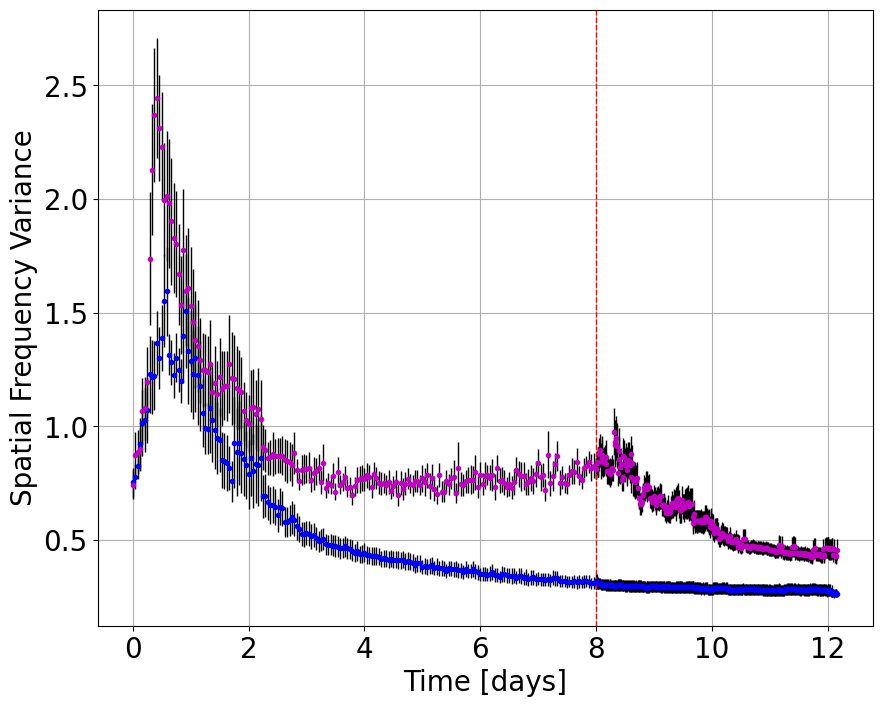

In [44]:
kk=R.SF_Var
μ=kk.mean(axis=1)  # average across neurons, at the end of a seq, for each channel
S=kk.std(axis=1)
N=kk.shape[1]
K=1+20/N**2
σ=K*S/np.sqrt(N)
errorbar(t,μ[:,strong_i],yerr=σ[:,strong_i],fmt='b.',lw=1,ecolor='k')
errorbar(t,μ[:,weak_i],yerr=σ[:,weak_i],fmt='m.',lw=1,ecolor='k')
ylabel('Spatial Frequency Variance')
xlabel('Time [days]')

ylim=gca().get_ylim()
vlines(t[idx1],*ylim,'r',lw=1,ls='--')
gca().set_ylim(ylim)




In [47]:
St=Storage()
for params in tqdm(all_params):
    sfname=params.sfname
    noise=params.noise[1]
    
    R=RR[sfname]

    
    idx1,idx2=[_[1] for _ in R.sequence_index]
    t=R.t/day
    recovery_rate_μ,recovery_rate_σ=μσ((R.ODI[idx2,:]-R.ODI[idx1,:])/(t[idx2]-t[idx1]))  

    ODI_μ2=R.ODI[idx2,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx2,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ2=K*S/np.sqrt(N)

    ODI_μ1=R.ODI[idx1,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx1,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ1=K*S/np.sqrt(N)


    SFV_recovery_rate_μ,SFV_recovery_rate_σ=μσ(
        (R.SF_Var[idx2,:]-R.SF_Var[idx1,:])/(t[idx2]-t[idx1]))  


    
    St+=noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2,SFV_recovery_rate_μ,SFV_recovery_rate_σ 

noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2,SFV_recovery_rate_μ,SFV_recovery_rate_σ=St.arrays()

glasses_result=noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2,SFV_recovery_rate_μ,SFV_recovery_rate_σ


100%|███████████████████████████████████████████| 11/11 [00:00<00:00, 50.20it/s]


0.10141484081308706 0.12950472557103923


Text(0.5, 1.0, 'Glasses Treatment')

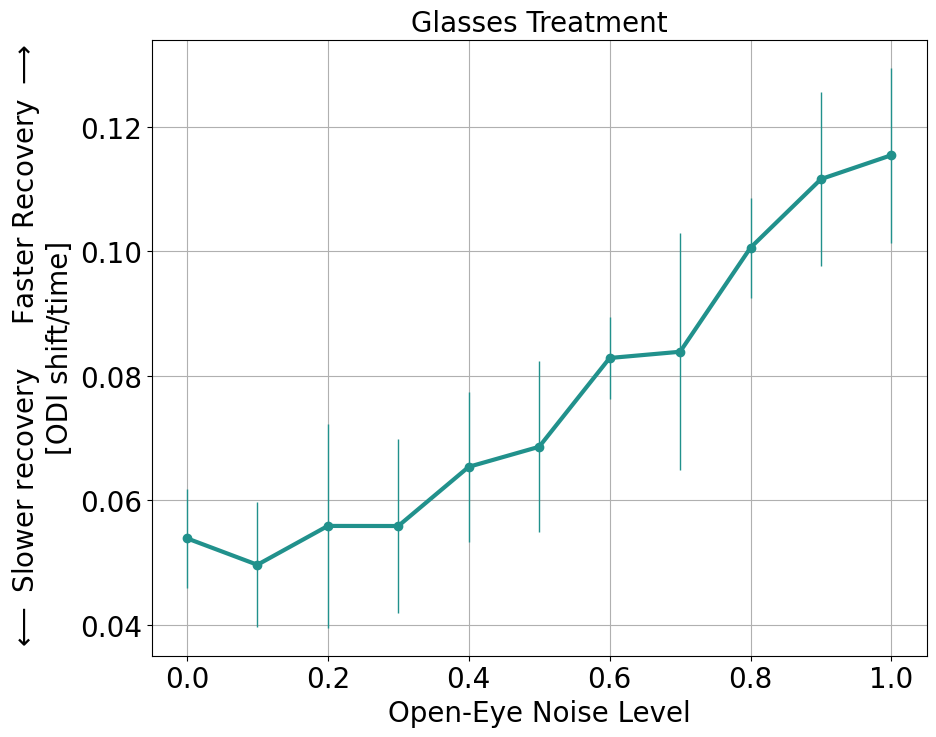

In [50]:
import cycler
colormap=cm.viridis

n = 5
#colormap=cm.Blues
#color = colormap(np.linspace(1, 0,int(1.2*n)))

colormap=cm.viridis
color = colormap(np.linspace(0, 1,n))

glasses_plot_color=cm.viridis(np.linspace(0, 1,5))[2]

noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2,SFV_recovery_rate_μ,SFV_recovery_rate_σ =glasses_result        

glasses_μ=-recovery_rate_μ
glasses_σ=2*recovery_rate_σ

# best case
idx=argmax(glasses_μ)
max_glasses=glasses_μ[idx]+glasses_σ[idx]
min_glasses=glasses_μ[idx]-glasses_σ[idx]
print(min_glasses,max_glasses)


errorbar(noise,-recovery_rate_μ,yerr=2*recovery_rate_σ,elinewidth=1,fmt='o-',color=color[2]) # positive = recovery
ylabel(r'$\longleftarrow$ Slower recovery     Faster Recovery $\longrightarrow$'+"\n[ODI shift/time]")
xlabel('Open-Eye Noise Level')
title('Glasses Treatment')

0.03555643265253863 0.096078889600346


Text(0.5, 1.0, 'Glasses Treatment')

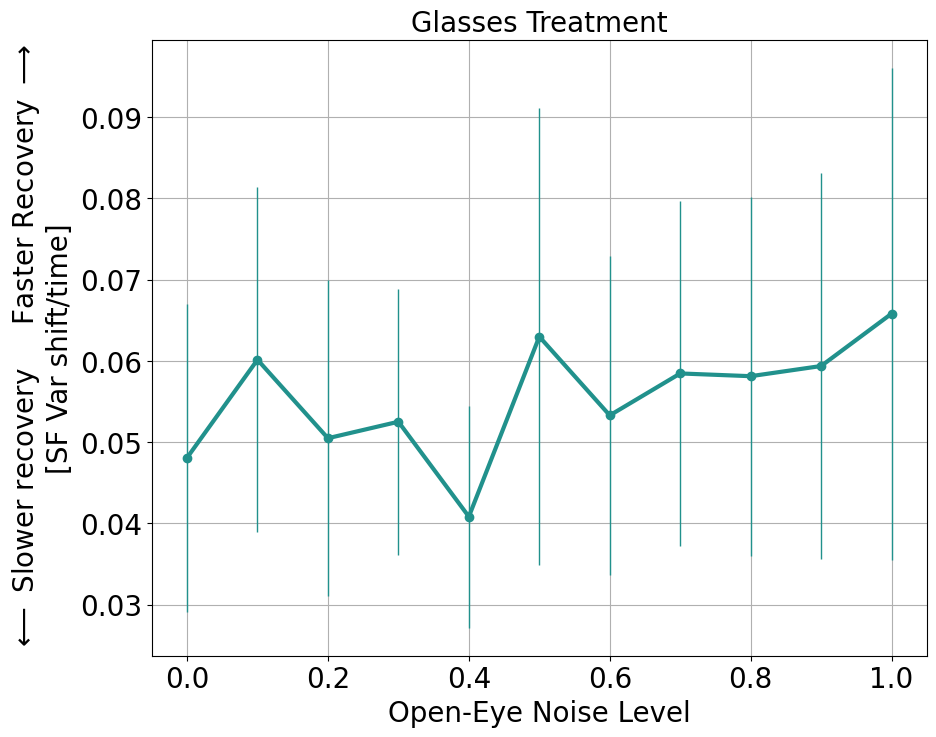

In [52]:
import cycler
colormap=cm.viridis

n = 5
#colormap=cm.Blues
#color = colormap(np.linspace(1, 0,int(1.2*n)))

colormap=cm.viridis
color = colormap(np.linspace(0, 1,n))

glasses_plot_color=cm.viridis(np.linspace(0, 1,5))[2]

noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2,SFV_recovery_rate_μ,SFV_recovery_rate_σ =glasses_result        

glasses_μ=-SFV_recovery_rate_μ
glasses_σ=2*SFV_recovery_rate_σ

# best case
idx=argmax(glasses_μ)
max_glasses=glasses_μ[idx]+glasses_σ[idx]
min_glasses=glasses_μ[idx]-glasses_σ[idx]
print(min_glasses,max_glasses)


errorbar(noise,-SFV_recovery_rate_μ,yerr=2*SFV_recovery_rate_σ,elinewidth=1,fmt='o-',color=color[2]) # positive = recovery
ylabel(r'$\longleftarrow$ Slower recovery     Faster Recovery $\longrightarrow$'+"\n[SF Var shift/time]")
xlabel('Open-Eye Noise Level')
title('Glasses Treatment')